Importing libraries

In [1]:
library(Seurat)
library(Signac)
library(BuenColors)
library(data.table)
library(dplyr)
library(stringr)
library(ggpubr)
library(ggpointdensity)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect


Loading required package: MASS

Loading required package: ggplot2


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
JAN_028_wnn=readRDS("~/JAN_028/JAN_028_common_processed_object_with_wnn_030124.RDS")

Importing the differential accessibility analysis

In [273]:
library(data.table)
library(readxl)
combined_DAP_JAN_028_ATAC=read_excel("~/github_reproducibility/table_s2.xlsx")
colnames(combined_DAP_JAN_028_ATAC)=combined_DAP_JAN_028_ATAC[2,]
combined_DAP_JAN_028_ATAC=combined_DAP_JAN_028_ATAC[-c(1,2),]
combined_DAP_JAN_028_ATAC

New names:
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`


peak_locus,log2FC,beta_weight,p_weight,perturbation_name
<chr>,<chr>,<chr>,<chr>,<chr>
chr5-168813327-168814237,-0.15514557617228,0.145987739852766,1.31096636387755e-08,ATF4
chr11-75534415-75535556,-5.5632183801225303E-2,0.103566702759262,1.36674203272749e-08,ATF4
chrY-19737481-19738387,-0.34304276319087301,0.25171182243380102,8.01546877865352e-08,ATF4
chr11-12144313-12145139,-0.427419489502256,0.51551921832171599,9.0638978295625e-08,ATF4
chr7-154909710-154910686,-0.98979262803490897,0.60948977260967097,4.75598972050028e-19,BCL11A
chr11-64007497-64008417,-0.28338816243140402,0.240035908143333,4.36867566648706e-18,BCL11A
chr10-86345983-86346951,-1.1034646327614299,0.50074353711771302,6.10111905797729e-18,BCL11A
chr17-10756340-10757325,-0.89499720457144305,0.461048174083665,2.71273790372006e-17,BCL11A
chr11-2303508-2304268,-0.20988260262115899,0.252592897451411,6.3056869867941e-17,BCL11A


Import TF-sensitive elements

In [4]:
library(data.table)
library(readxl)
combined_DAP_JAN_028_RNA=read_excel("~/github_reproducibility/table_s3.xlsx")
colnames(combined_DAP_JAN_028_RNA)=combined_DAP_JAN_028_RNA[2,]
combined_DAP_JAN_028_RNA=combined_DAP_JAN_028_RNA[-c(1,2),]
combined_DAP_JAN_028_RNA

New names:
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`


gene_ID,log2FC,beta_weight,p_weight,perturbation_name
<chr>,<chr>,<chr>,<chr>,<chr>
MT-ND3,-9.0136847972572404E-2,0.15533586633977001,5.3648804570835403E-37,ATF4
MT-ND2,-5.9501249162944497E-2,0.184772069516459,3.7932662245125702E-36,ATF4
PF4,0.29658374428265699,-1.0308258222860101,4.4550330112114897E-34,ATF4
NPM1,2.4261117345942398E-2,-0.16447876595611199,1.6779283998311699E-30,ATF4
MT-CO1,-6.8205578071789397E-2,0.122407471925083,1.45176064585498E-29,ATF4
MT-ND4,-7.8312301809056406E-2,0.171366534644463,5.2340105415643603E-29,ATF4
MT-CO2,-0.10827527887327899,0.162958939212307,9.9246421356248597E-29,ATF4
TIMP1,-6.4981038232525296E-2,-0.293665087456632,2.6136792649915098E-28,ATF4
RPL14,2.9836347159906601E-2,-9.8726733980422907E-2,1.0948262692852901E-27,ATF4


In [5]:
DefaultAssay(JAN_028_wnn)='ATAC'

Importing the object from 
perturb_multiome/TF_sensitive_element_computation
/GITHUB_TF_sensitive_element_computation.ipynb

In [ ]:
#seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC=readRDS("~/github_reproducibility/seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC.RDS")

In [6]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA_metadata=read.table("JAN_028_seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA.csv")

In [7]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC_metadata=read.table("JAN_028_seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC.csv")



In [8]:
JAN_028_wnn_with_module=JAN_028_wnn

In [9]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA_metadata$ATAC_mixscale_score=seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC_metadata$mixscale_score



In [13]:
JAN_028_wnn_with_module@meta.data$perturbation_name=seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC_metadata$perturbation_name
JAN_028_wnn_with_module@meta.data$mixscale_score=seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC_metadata$mixscale_score




Importing correlations. These are the ouput from the WDL for correlations and figR_script_by_target.R

In [ ]:
cd ~/github_reproducibility/PER_TF_all_peaks_and_perturbations_correlation_analysis
COUNTER=1
for PADDING joinin 1 2 3 4 5 6 7 8 9 10 11; do 
    
    gsutil ls "gs://bucket_path/JAN_028/figR/ALL_TFs_all_peaks_BY_TARGET_PADDING_${PADDING}//*_correlations.csv" | while read -r srcFile; do
        baseName=$(basemname "$srcFile")
        gsutil cp "$srcFile" "{COUNTER}_
{baseName}"        
    done
    ((COUNTER++))
done

In [ ]:
#setwd("~/github_reproducibility/PER_TF_all_peaks_and_perturbations_correlation_analysis")

files <- list.files(pattern = "_correlations\\.csv$")

read_and_append_filename <- function(filename) {
  df <- read.csv(filename, sep=' ')
    modified_name <- gsub("^\\d+_", "", basename(filename))
  base_name <- tools::file_path_sans_ext(gsub("_correlations", "", modified_name))
    df$target <- base_name
  return(df)
}

combined_correlations_all_tfs <- do.call(rbind, lapply(files, read_and_append_filename))

combined_correlations_all_tfs = combined_correlations_all_tfs %>%
  mutate(target_and_peak = paste0(target, "_", gsub(":", "-", PeakRanges)))


In [ ]:
#fwrite(combined_correlations_all_tfs,"~/github_reproducibility/combined_correlations_all_tfs.csv")

In [ ]:
library(data.table)
combined_correlations_all_tfs=fread("~/github_reproducibility/combined_correlations_all_tfs.csv")


In [284]:
library(Seurat)
JAN_028_wnn_with_module@meta.data=JAN_028_wnn_with_module@meta.data[,c(1:10)]

transcription_factors <- c("GFI1B") 

for (tf in transcription_factors) {
  
  TF_correlations <- combined_correlations_all_tfs %>%
    filter(perturbation_name == tf)
  
  TF_DAP <- combined_DAP_JAN_028_ATAC %>%
    filter(perturbation_name == tf) %>%
    filter(p_weight < 0.05 / 230000)
  
  TF_correlations$PeakRanges <- gsub(":", "-", TF_correlations$PeakRanges)
  
  TF_DAP <- TF_DAP %>%
    mutate(target_and_peak = paste0(tf, "_", peak_locus))
  
  TF_correlations <- TF_correlations %>%
    mutate(target_and_peak = paste0(tf, "_", peaks))
  
  TF_DAP_correlations <- merge(TF_DAP, TF_correlations, by = 'target_and_peak')
  
  combined_DAP_JAN_028_RNA_TF <- combined_DAP_JAN_028_RNA %>%
    filter(perturbation_name == tf)
  
  TF_DAP_correlations_AND_RNA <- merge(combined_DAP_JAN_028_RNA_TF, TF_DAP_correlations,
                                       by.x = 'gene_ID', by.y = 'Gene')
  
  sig_RNA <- TF_DAP_correlations_AND_RNA %>%
    filter(p_weight.x < 0.05 / 23508) %>%
    pull(gene_ID)

  
  correlated_RNA_from_sig_ATAC <- TF_DAP_correlations_AND_RNA %>%
    filter(p_weight.y < 0.05 / 230000) %>%
    filter(pvalZ_collapse_NT < 0.1) %>%
    filter(rObs_collapse_NT > 0.03)%>%
    pull(gene_ID)

  DefaultAssay(JAN_028_wnn_with_module) <- 'RNA'
  
 JAN_028_wnn_with_module <- AddModuleScore(JAN_028_wnn_with_module,
       
                                            list(sig_RNA), name = paste0("sig_RNA_", tf))
    
  
  JAN_028_wnn_with_module <- AddModuleScore(JAN_028_wnn_with_module,
                                            list(correlated_RNA_from_sig_ATAC),
                                            name = paste0("correlated_RNA_from_sig_ATAC_", tf))

module_score_names <- c(
  "correlated_RNA_from_sig_ATAC_",
    "sig_RNA_"
)

for (module_score in module_score_names) {
  zscored_name <- paste0("zscored_", module_score, tf, "1") 
  raw_score_name <- paste0(module_score, tf, "1") 
  
  JAN_028_wnn_with_module@meta.data <- JAN_028_wnn_with_module@meta.data %>%
    mutate(!!zscored_name :=
             (get(raw_score_name) - mean(get(raw_score_name), na.rm = TRUE)) /
             sd(get(raw_score_name), na.rm = TRUE))
}

  
  JAN_028_wnn_with_module@meta.data$mixscale_score <- seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC_metadata$mixscale_score
  

}


`geom_smooth()` using formula = 'y ~ x'


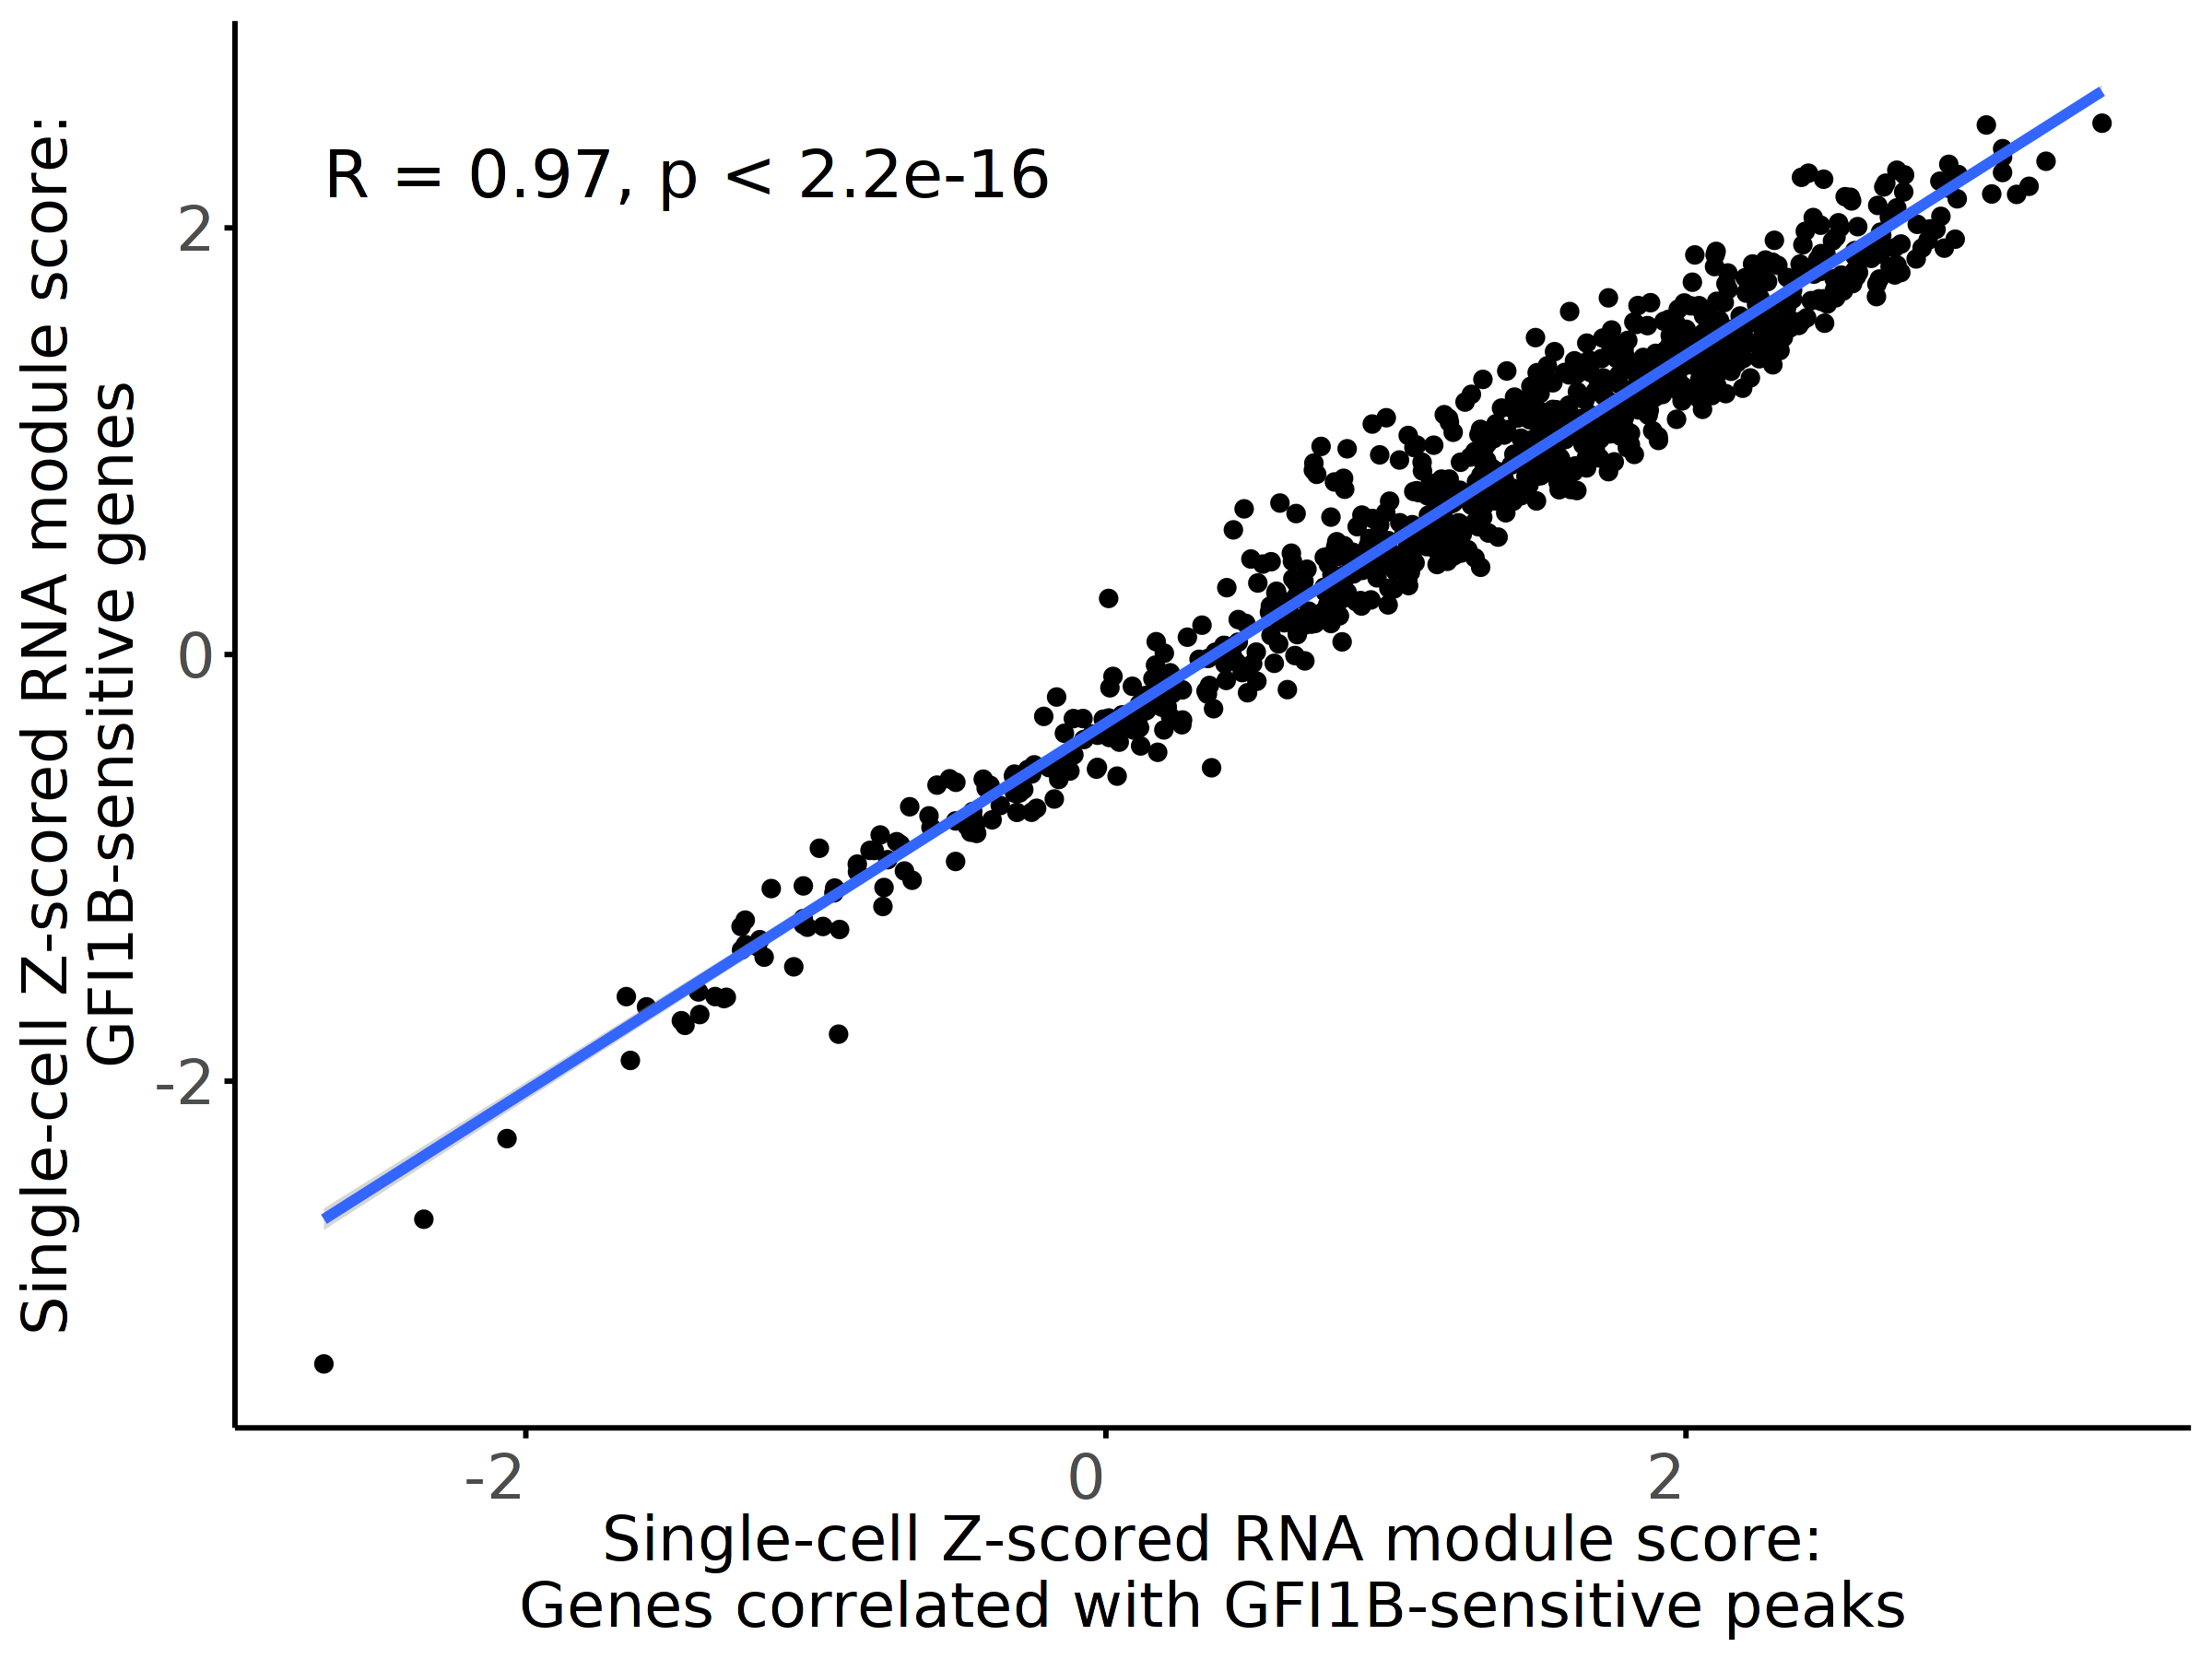

In [285]:
library(viridis)
library(ggplot2)
library(dplyr)

width <- 8
height <- 6
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 300)

transcription_factors <- c("GFI1B")

scenarios <- c(
  "zscored_correlated_RNA_from_sig_ATAC_"
)

output_folder <- "~/0_perturb_multiome_manuscript_figures/"

if (!dir.exists(output_folder)) dir.create(output_folder)

for (tf in transcription_factors) {
  for (scenario in scenarios) {
    
    figure_name <- paste0("JAN_028_", tf, "_", scenario, "RNA_module_correlation_ATAC_correlated_genes_2nd_revision.pdf")
    
    JAN_028_wnn_with_module_TF_cells_only <- JAN_028_wnn_with_module[, row.names(JAN_028_wnn_with_module@meta.data %>%
                                                                                   filter(gene == tf))]
    
    JAN_028_wnn_with_module_TF_cells_only@meta.data <- JAN_028_wnn_with_module_TF_cells_only@meta.data %>%
      mutate(!!paste0("mixscale_zscored_for_", tf, "_cells") :=
               (mixscale_score - mean(mixscale_score)) / sd(mixscale_score))
    
    tf_cells_data <- JAN_028_wnn_with_module_TF_cells_only@meta.data %>%
      filter(get(paste0("mixscale_zscored_for_", tf, "_cells")) > 1)
    
    x_col <- paste0(scenario, tf, "1") 
    y_col <- paste0("zscored_sig_RNA_", tf, "1") 
    
    plot <- ggplot(tf_cells_data, 
                   aes(x = get(x_col),
                       y = get(y_col))) +
      geom_point() + 
      geom_smooth(method = "lm", se = TRUE) + 
      stat_cor(method = "spearman", size = 6) + 
      theme_minimal() +
      theme(
        axis.ticks = element_line(color = "black"),
        text = element_text(size = 16),
        axis.title = element_text(size = 16),
        axis.text.x = element_text(angle = 0, hjust = 1, vjust = 0.5, size = 16),
        axis.text.y = element_text(size = 16),
        panel.background = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        strip.text = element_text(size = 16),
        strip.background = element_blank()
      ) +
      xlab(paste0("Single-cell Z-scored RNA module score:\nGenes correlated with ", tf, "-sensitive peaks")) +
      ylab(paste0("Single-cell Z-scored RNA module score:\n", tf, "-sensitive genes")) +
      scale_color_viridis(name = "Perturbation score")
    
    print(plot)
    
    #ggsave(filename = paste0(output_folder, figure_name),
     #      plot = plot, dpi = 600, width = width, height = height)
  }
}
